In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

data = {
  'biaya_iklan': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    'jumlah_sales': [2, 3, 3, 4, 5, 5, 6, 7, 8, 8],
    'persen_diskon': [2, 5, 5, 10, 10, 12, 15, 15, 18, 20],
    'unit_terjual': [50, 65, 72, 85, 98, 105, 120, 135, 150, 165]
}

df = pd.DataFrame(data)
print(df)

   biaya_iklan  jumlah_sales  persen_diskon  unit_terjual
0           10             2              2            50
1           15             3              5            65
2           20             3              5            72
3           25             4             10            85
4           30             5             10            98
5           35             5             12           105
6           40             6             15           120
7           45             7             15           135
8           50             8             18           150
9           55             8             20           165



Pada praktikum Regresi Linear Berganda ini, saya membuat data sendiri yang menggambarkan hubungan antara biaya iklan, jumlah sales, dan persen diskon terhadap total unit mobil yang terjual. Data terdiri dari 10 sampel dengan variasi biaya iklan dari 10 hingga 55 juta, jumlah tenaga sales 2 hingga 8 orang, serta besaran diskon 2% hingga 20%. Tema ini dipilih karena secara logis volume penjualan sebuah produk tidak hanya dipengaruhi oleh satu faktor saja, melainkan hasil dari kombinasi strategi pemasaran, kekuatan tim lap

In [18]:
X = df[['biaya_iklan', 'jumlah_sales', 'persen_diskon']]
y = df['unit_terjual']
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [19]:

print("Intercept (a) : ", model.intercept_)
print("Koefisien (b) : ", model.coef_)

Intercept (a) :  18.98780487804882
Koefisien (b) :  [ 2.01219512  4.52439024 -0.29268293]


In [20]:
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Nilai Asli:", y_test.values)

Prediksi: [150.52439024  61.2804878 ]
Nilai Asli: [150  65]


Berdasarkan hasil training, model menghasilkan intercept dan tiga koefisien. Setiap koefisien menunjukkan seberapa besar pengaruh masing-masing variabel terhadap unit terjual jika variabel lain dianggap tetap. Koefisien dengan nilai terbesar berarti variabel tersebut paling dominan mempengaruhi unit yg terjual.

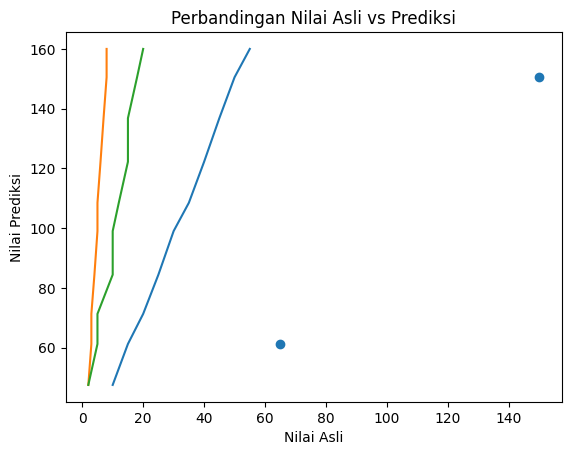

In [21]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.plot(X, model.predict(X), label="Garis Regresi")
plt.xlabel("Nilai Asli")
plt.ylabel("Nilai Prediksi")
plt.title("Perbandingan Nilai Asli vs Prediksi")
plt.show()

In [22]:

print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 2.1219512195121766
MSE: 7.054878048780421
RMSE: 2.656102040355457


Evaluasi Model Metrik dan Interpretasi :



* MAE : Rata-rata selisih antara konsumsi aktual dan prediksi
* MSE : Rata-rata kuadrat error — lebih sensitif terhadap prediksi yang meleset jauh
* RMSE : Akar dari MSE

satuannya sama dengan data asli — lebih mudah diinterpretasikan